In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import roc_curve, auc, roc_auc_score, precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv('/Users/sashabates/Desktop/4320/assignment5/telco_churn.csv')

print("Shape:", df.shape)
print("\nData types:")
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum())
print("\nChurn distribution:")
print(df['Churn'].value_counts())
print("\nChurn proportions:")
print(df['Churn'].value_counts(normalize=True))

Shape: (7043, 12)

Data types:
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
InternetService      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                 int64
dtype: object

Missing values:
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
InternetService     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Churn distribution:
Churn
0    5174
1    1869
Name: count, dtype: int64

Churn proportions:
Churn
0    0.73463
1    0.26537
Name: proportion, dtype: float64


In [9]:
# Stratified split: 70% train, 15% val, 15% test
X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=20
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=20
)

print("Split sizes:")
print(f"Train: {X_train.shape[0]} ({X_train.shape[0] / len(df) * 100:.1f}%)")
print(f"Val:   {X_val.shape[0]} ({X_val.shape[0] / len(df) * 100:.1f}%)")
print(f"Test:  {X_test.shape[0]} ({X_test.shape[0] / len(df) * 100:.1f}%)")

print("\nChurn distribution:")
print(f"Train: {y_train.value_counts(normalize=True).to_dict()}")
print(f"Val:   {y_val.value_counts(normalize=True).to_dict()}")
print(f"Test:  {y_test.value_counts(normalize=True).to_dict()}")

Split sizes:
Train: 4930 (70.0%)
Val:   1056 (15.0%)
Test:  1057 (15.0%)

Churn distribution:
Train: {0: 0.734685598377282, 1: 0.2653144016227181}
Val:   {0: 0.7348484848484849, 1: 0.26515151515151514}
Test:  {0: 0.7341532639545885, 1: 0.26584673604541154}


In [10]:
# Split numeric and categorical
numeric_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = X_train.select_dtypes(include=['object']).columns.tolist()

# Preprocess
preprocessor = ColumnTransformer([
    ('num', Pipeline([
        ('impute', SimpleImputer(strategy='median')),
        ('scale', StandardScaler())
    ]), numeric_cols),
    ('cat', Pipeline([
        ('impute', SimpleImputer(strategy='most_frequent')),
        ('encode', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ]), categorical_cols)
])

# Fit on train only, transform all
X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)

print(f"Processed: Train {X_train_processed.shape}, Val {X_val_processed.shape}, Test {X_test_processed.shape}")

Processed: Train (4930, 4671), Val (1056, 4671), Test (1057, 4671)


In [11]:
# Full pipeline: preprocessing + logistic regression
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=20))
])

#training data
pipeline.fit(X_train, y_train)

# validation set
y_val_pred = pipeline.predict(X_val)

acc = accuracy_score(y_val, y_val_pred)
prec = precision_score(y_val, y_val_pred)
rec = recall_score(y_val, y_val_pred)
f1 = f1_score(y_val, y_val_pred)

print("Validation Metrics:")
print(f"Accuracy:  {acc:.3f}")
print(f"Precision: {prec:.3f}")
print(f"Recall:    {rec:.3f}")
print(f"F1-Score:  {f1:.3f}")

Validation Metrics:
Accuracy:  0.7973
Precision: 0.6435
Recall:    0.5286
F1-Score:  0.5804


In [13]:
# Confusion matrix
cm = confusion_matrix(y_val, y_val_pred)
tn, fp, fn, tp = cm.ravel()

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[694  82]
 [132 148]]


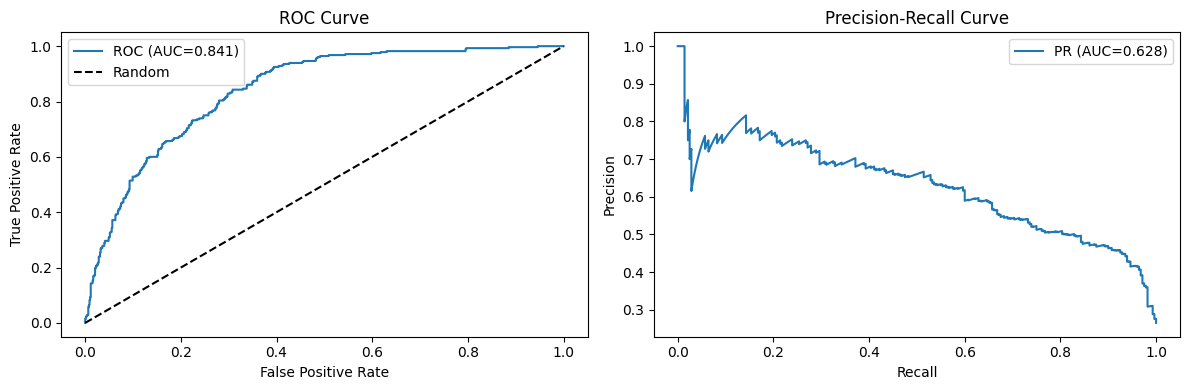

ROC AUC:  0.8411
PR AUC:   0.6281


In [14]:
# Get predicted probabilities
y_val_proba = pipeline.predict_proba(X_val)[:, 1]

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_val, y_val_proba)
roc_auc = roc_auc_score(y_val, y_val_proba)

# Precision-Recall Curve
precision_vals, recall_vals, pr_thresholds = precision_recall_curve(y_val, y_val_proba)
pr_auc = average_precision_score(y_val, y_val_proba)

# Plot both
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(fpr, tpr, label=f'ROC (AUC={roc_auc:.3f})')
ax1.plot([0, 1], [0, 1], 'k--', label='Random')
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.legend()
ax1.set_title('ROC Curve')

ax2.plot(recall_vals, precision_vals, label=f'PR (AUC={pr_auc:.3f})')
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.legend()
ax2.set_title('Precision-Recall Curve')

plt.tight_layout()
plt.show()

print(f"ROC AUC:  {roc_auc:.4f}")
print(f"PR AUC:   {pr_auc:.4f}")

In [17]:
# Compare thresholds
thresholds_to_test = [0.3, 0.4, 0.5, 0.7]

print("Threshold Comparison:")
print("-" * 80)
print(f"{'Threshold':<12} {'Precision':<12} {'Recall':<12} {'F1-Score':<12} {'Accuracy':<12}")
print("-" * 80)

results = {}
for thresh in thresholds_to_test:
    y_pred_thresh = (y_val_proba >= thresh).astype(int)
    prec = precision_score(y_val, y_pred_thresh)
    rec = recall_score(y_val, y_pred_thresh)
    f1 = f1_score(y_val, y_pred_thresh)
    acc = accuracy_score(y_val, y_pred_thresh)
    results[thresh] = {'prec': prec, 'rec': rec, 'f1': f1, 'acc': acc}
    print(f"{thresh:<12.1f} {prec:<12.3f} {rec:<12.3f} {f1:<12.3f} {acc:<12.3f}")

print("-" * 80)

# CHOOSE THRESHOLD
chosen_threshold = 0.4
chosen_metrics = results[chosen_threshold]

print(f"\n>>> CHOSEN THRESHOLD: {chosen_threshold}")
print(f"    Precision: {chosen_metrics['prec']:.3f} - When we predict churn, we're right {chosen_metrics['prec']*100:.1f}% of the time")
print(f"    Recall:    {chosen_metrics['rec']:.3f} - We catch {chosen_metrics['rec']*100:.1f}% of actual churners")
print(f"    F1-Score:  {chosen_metrics['f1']:.3f}")
print(f"\nReason: 0.4 balances precision & recall better than default 0.5")
print(f"        Catching churners is more important than false alarms in telecom")

Threshold Comparison:
--------------------------------------------------------------------------------
Threshold    Precision    Recall       F1-Score     Accuracy    
--------------------------------------------------------------------------------
0.3          0.540        0.729        0.620        0.763       
0.4          0.594        0.621        0.607        0.787       
0.5          0.643        0.529        0.580        0.797       
0.7          0.744        0.218        0.337        0.773       
--------------------------------------------------------------------------------

>>> CHOSEN THRESHOLD: 0.4
    Precision: 0.594 - When we predict churn, we're right 59.4% of the time
    Recall:    0.621 - We catch 62.1% of actual churners
    F1-Score:  0.607

Reason: 0.4 balances precision & recall better than default 0.5
        Catching churners is more important than false alarms in telecom


In [18]:
# Final evaluation on test set with chosen threshold 0.4
y_test_proba = pipeline.predict_proba(X_test)[:, 1]
chosen_threshold = 0.4
y_test_pred = (y_test_proba >= chosen_threshold).astype(int)

test_acc = accuracy_score(y_test, y_test_pred)
test_prec = precision_score(y_test, y_test_pred)
test_rec = recall_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred)

print("=" * 70)
print("FINAL TEST EVALUATION (Threshold = 0.4)")
print("=" * 70)
print(f"Test Accuracy:  {test_acc:.4f}")
print(f"Test Precision: {test_prec:.4f}")
print(f"Test Recall:    {test_rec:.4f}")
print(f"Test F1-Score:  {test_f1:.4f}")

print("\n" + "=" * 70)
print("VALIDATION vs TEST COMPARISON")
print("=" * 70)
print(f"{'Metric':<12} {'Validation':<15} {'Test':<15} {'Difference':<15}")
print("-" * 70)
print(f"{'Accuracy':<12} {accuracy_score(y_val, (y_val_proba >= 0.4).astype(int)):<15.4f} {test_acc:<15.4f} {test_acc - accuracy_score(y_val, (y_val_proba >= 0.4).astype(int)):<15.4f}")
print(f"{'Precision':<12} {precision_score(y_val, (y_val_proba >= 0.4).astype(int)):<15.4f} {test_prec:<15.4f} {test_prec - precision_score(y_val, (y_val_proba >= 0.4).astype(int)):<15.4f}")
print(f"{'Recall':<12} {recall_score(y_val, (y_val_proba >= 0.4).astype(int)):<15.4f} {test_rec:<15.4f} {test_rec - recall_score(y_val, (y_val_proba >= 0.4).astype(int)):<15.4f}")
print(f"{'F1-Score':<12} {f1_score(y_val, (y_val_proba >= 0.4).astype(int)):<15.4f} {test_f1:<15.4f} {test_f1 - f1_score(y_val, (y_val_proba >= 0.4).astype(int)):<15.4f}")

print("\n" + "=" * 70)
print("ANALYSIS")
print("=" * 70)
print("If test metrics are close to validation: Model generalizes well")
print("If test metrics are much worse: Possible overfitting or test distribution differs")
print("Small differences (±0.02) are normal due to random sample variation")

FINAL TEST EVALUATION (Threshold = 0.4)
Test Accuracy:  0.7796
Test Precision: 0.5784
Test Recall:    0.6299
Test F1-Score:  0.6031

VALIDATION vs TEST COMPARISON
Metric       Validation      Test            Difference     
----------------------------------------------------------------------
Accuracy     0.7869          0.7796          -0.0074        
Precision    0.5939          0.5784          -0.0154        
Recall       0.6214          0.6299          0.0085         
F1-Score     0.6073          0.6031          -0.0043        

ANALYSIS
If test metrics are close to validation: Model generalizes well
If test metrics are much worse: Possible overfitting or test distribution differs
Small differences (±0.02) are normal due to random sample variation
